In [1]:
import numpy as np
from scipy.optimize import minimize
import pandas as pd
import GPy
from scipy.special import expit
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from scipy.spatial import distance
import statsmodels.api as sm
import warnings
import numpy as np
from scipy.optimize import differential_evolution
from scipy.stats import rankdata
from sklearn.cross_decomposition import CCA
import math
import copy
from math import log
from collections import Counter
import pickle
from sklearn.linear_model import Lasso
warnings.filterwarnings("ignore")

In [2]:
# Read beta back from the file
beta_star = np.load('beta_star.npy')
print("beta_star:", beta_star)
n_features = len(beta_star)

np.sum(beta_star[beta_star > 0])

beta_star: [ 0.          0.          0.          0.          0.          0.
  0.          0.         -9.35929044 -8.23056672  0.          0.
  0.          0.          0.          0.          0.         -1.93149689
  0.          0.          0.          0.          0.          0.
  0.          0.         -4.01959343  0.          4.46057556  0.
  0.          0.          0.          0.          0.          0.
  0.          0.          3.62310545  0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          2.16801674  0.          0.
  0.         -1.45199639  0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  5.18683686  0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.  

15.438534611441117

In [26]:
from sklearn.linear_model import Lasso

def lasso_stochastic_bandit(phi, T, C_max_wave, L, error_std, Y_t, X_t, beta_star):
    """
    Implements the preconditioning LASSO bandit algorithm.

    Args:
        phi (float): Regularization parameter for optimization.
        T (int): Total time steps.
        C_max_wave (float): F_t matrix eigenvalue constraint.
        L (float): Upper limit for X values.
        error_std (float): Standard deviation for error term.
        Y_t (array): Initial response vector.
        X_t (array): Initial feature matrix.
        beta_star (array): True coefficient vector for simulation.

    Returns:
        Y_t, X_t: Updated response vector and feature matrix.
    """
    n_features = X_t.shape[1]  # Number of features

    Y_t_exp = Y_t

    l_2_error_parameter = np.array([])

    for tau in range(len(Y_t), T):
        # Compute lambda for LASSO
        lamada = 2 * error_std * C_max_wave * L * np.sqrt(2 * (2 * np.log(tau) + np.log(n_features)) / tau)

        # Perform LASSO regression with lambda using Y_t_tran and X_t_tran
        lasso = Lasso(alpha=lamada, fit_intercept=False)
        lasso.fit(X_t, Y_t)  # Fit the model to get beta estimates
        beta_esti = lasso.coef_  # Estimated beta values
        print(f"parameter square error:{np.sqrt(sum((beta_esti - beta_star)**2))}")
        s_esti = np.count_nonzero(beta_esti)  # Number of non-zero coefficients

        # Perform optimization to find X_max
        # Check if expected Y_t has not changed for 20 iterations
        if len(Y_t_exp) >= 20 and np.all(Y_t_exp[-20:] == Y_t_exp[-1]):
            # Keep X_max unchanged
            X_max = X_t[-1]
        else:
            if len(Y_t_exp) <= 500:
                # Perform optimization to find X_max
                X_max = optimization(beta_esti, s_esti, X_t, L, lamada, phi, tau)
            else:
                X_max = optimization_no_variance(beta_esti, s_esti, X_t, L, lamada, tau)

        # Generate Y_max based on true beta_star
        Y_max = beta_star @ X_max + np.random.normal(0, error_std, 1)

        # Generate Y_max based on true beta_star
        Y_max_exp = beta_star @ X_max
    
        print(f"time {tau}: mean reward {beta_star @ X_max}")
        #print(f"time {tau}: action {X_max}")

        l_2_error_parameter = np.append(l_2_error_parameter, np.sqrt(sum((beta_esti - beta_star)**2)))

        # Append X_max and Y_max to X_t and Y_t
        Y_t = np.append(Y_t, Y_max)
        X_t = np.vstack([X_t, X_max])

        Y_t_exp = np.append(Y_t_exp, Y_max_exp)

    return Y_t, X_t, Y_t_exp, l_2_error_parameter


In [22]:
def optimization(beta_esti, s_esti, X_t, L, lamada, phi, tau):
    """
    Perform optimization using a hill-climbing algorithm under given constraints.

    Args:
        beta_esti (numpy array): Estimated coefficients (beta).
        s_esti (float): Estimated parameter for scaling.
        X_t (numpy array): Existing feature matrix.
        lamada (float): Regularization parameter.
        phi (float): Parameter for constraint.
        C_max_wave (float): Constraint for F_t matrix eigenvalue.
        t (int): Time step or scaling factor.
        max_iterations (int): Maximum number of iterations for the algorithm.

    Returns:
        numpy array: Optimized X_max vector.
    """
    # Define the objective function
    # Define the objective function
    def objective(X_max):
        X_max = np.array(X_max)
        sqrt_term = np.sqrt(X_max @ np.linalg.pinv((1 / tau) * (X_t.T @ X_t)) @ X_max.reshape(-1, 1))
        constant = (4 * np.sqrt(s_esti) * lamada / phi)
        return -(beta_esti @ X_max + constant * sqrt_term)  # Negate for maximization
    
    # Initial guess for X_max
    X_max_initial = np.random.uniform(0, L, size=len(beta_esti))
    
    # Set bounds for each variable in X_max [0, L]
    bounds = [(0, L) for _ in range(len(beta_esti))]
    
    # Perform optimization
    result = minimize(objective, X_max_initial, bounds=bounds)
    
    # Output the result
    if result.success:
        X_max_optimal = result.x
    else:
        X_max_optimal = X_max_initial
        print("Optimization failed:", result.message)


    return X_max_optimal


In [23]:
def optimization_no_variance(beta_esti, s_esti, X_t, L, lamada, tau):

    # Define the objective function
    # Define the objective function
    def objective(X_max):
        X_max = np.array(X_max)
        return -(beta_esti @ X_max)  # Negate for maximization
    
    # Initial guess for X_max
    X_max_initial = np.random.uniform(0, L, size=len(beta_esti))
    
    # Set bounds for each variable in X_max [0, L]
    bounds = [(0, L) for _ in range(len(beta_esti))]
    
    # Perform optimization
    result = minimize(objective, X_max_initial, bounds=bounds)
    
    # Output the result
    if result.success:
        X_max_optimal = result.x
    else:
        print("Optimization failed:", result.message)


    return X_max_optimal

# Lasso Stochastic Bandit

In [27]:
def while_lasso_stochastic_bandit(beta_star):
    error_std = 1
    phi = 10
    C_max_wave = 1
    t = 2
    T = 1000 + t
    L = 1
    # Generate X where the first column is 1, and the remaining columns are random values
    X_t = np.ones((t, n_features))  # Start with an array of ones
    X_t[:, 1:] = np.random.uniform(0, L, (t, n_features - 1))  # Fill the remaining columns with random values
    
    # Generate random error term
    error_t = np.random.normal(0, error_std, t)
    
    # Compute Y = X @ beta_star + error_t
    Y_t = X_t @ beta_star + error_t
    
    Y_T, X_T, Y_t_exp, l_2_error_parameter = lasso_stochastic_bandit(phi, T, C_max_wave, L, error_std, Y_t, X_t, beta_star)

    return Y_t_exp, l_2_error_parameter

In [28]:
cumulative_regre_times = []
l_2_error_parameter_times = []

# Run the experiment 10 times
for times in range(10):
    # Ensure beta_star and `t` are properly initialized
    Y_t_exp, l_2_error_parameter = while_lasso_stochastic_bandit(beta_star)  # Replace with the actual function
    Y_t_to_T = Y_t_exp
    
    # Calculate instantaneous regret
    instantaneous_regret = np.sum(beta_star[beta_star > 0]) - Y_t_to_T
    instantaneous_regret = np.where(instantaneous_regret < 0.002, 0, instantaneous_regret)  # Threshold adjustment

    # Calculate cumulative regret
    cumulative_regret = np.cumsum(instantaneous_regret)

    # Append results to the list
    cumulative_regre_times.append(cumulative_regret)
    l_2_error_parameter_times.append(l_2_error_parameter)

# The results `cumulative_regre_times` and `l_2_error_parameter_times` now store the outcomes of all experiments.

parameter square error:16.242629236512308
time 2: mean reward -7.924587103248244
parameter square error:16.242629236512308
time 3: mean reward -9.165980458343736
parameter square error:16.380859732264984
time 4: mean reward -1.4519963903118565
parameter square error:16.291552925118836
time 5: mean reward -9.734274169131332
parameter square error:16.448620944476108
time 6: mean reward 3.04032438284277
parameter square error:16.364828245799927
time 7: mean reward 2.19261331491267
parameter square error:16.308184612556836
time 8: mean reward -17.238579589516007
parameter square error:16.7116847715617
time 9: mean reward -17.27032480002284
parameter square error:16.764487337478126
time 10: mean reward -14.980858297275116
parameter square error:12.719321286995047
time 11: mean reward -7.188181382003625
parameter square error:12.954013344873609
time 12: mean reward -0.6115035691953166
parameter square error:13.105671848620501
time 13: mean reward -8.842070290137979
parameter square error:14.

In [29]:
# Convert lists to NumPy arrays for easier computation
cumulative_regret_times = np.array(cumulative_regre_times)
l_2_error_parameter_times = np.array(l_2_error_parameter_times)

# Calculate the mean and standard deviation along the "times" axis
cumulative_regret_mean = np.mean(cumulative_regret_times, axis=0)
cumulative_regret_std = np.std(cumulative_regret_times, axis=0)

l_2_error_parameter_mean = np.mean(l_2_error_parameter_times, axis=0)
l_2_error_parameter_std = np.std(l_2_error_parameter_times, axis=0)

# Print or use the results as needed
print("Cumulative Regret Mean:", cumulative_regret_mean)
print("Cumulative Regret Std:", cumulative_regret_std)
print("L2 Error Parameter Mean:", l_2_error_parameter_mean)
print("L2 Error Parameter Std:", l_2_error_parameter_std)

Cumulative Regret Mean: [  22.34529907   44.20288936   66.89435351 ... 4183.38682598 4185.63612582
 4187.42255485]
Cumulative Regret Std: [  3.10215173   5.26129212   7.391854   ... 243.11541382 243.15207704
 243.61283504]
L2 Error Parameter Mean: [16.5120623  16.53905509 16.62109212 16.44609145 16.69318108 16.61992841
 15.86179664 16.3313437  15.98067415 15.6794273  14.84248334 14.71018626
 14.52372474 14.16647596 14.35846877 14.34473385 14.24411229 14.01080619
 13.57030544 13.54654184 13.4291385  13.43691582 13.17589724 13.04682893
 13.04032905 12.85190132 12.98159497 13.05560617 12.78219406 12.42147323
 12.47476058 12.28951852 12.30120077 12.31654077 12.29636509 12.35040833
 12.29912988 12.22619547 12.21717217 12.19006772 12.23613569 12.24536614
 12.20528934 12.11611581 11.99208832 11.84505004 11.77070791 11.66789497
 11.62403819 11.61323709 11.55847161 11.53404926 11.49660142 11.43272853
 11.41057548 11.39983795 11.41746302 11.38313135 11.36155414 11.32886141
 11.35394033 11.359323

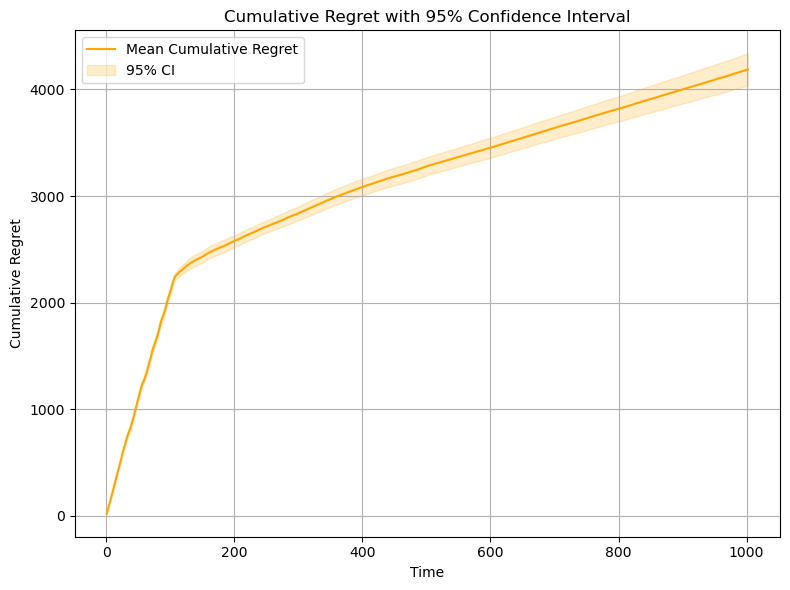

In [30]:
# Calculate the 95% confidence interval for the cumulative regret
lower_bound = cumulative_regret_mean - 1.96 * (cumulative_regret_std / np.sqrt(cumulative_regret_times.shape[0]))
upper_bound = cumulative_regret_mean + 1.96 * (cumulative_regret_std / np.sqrt(cumulative_regret_times.shape[0]))

# Plot the mean cumulative regret with confidence intervals
plt.figure(figsize=(8, 6))
time_steps = range(1, len(cumulative_regret_mean) + 1)

# Plot the mean line
plt.plot(time_steps, cumulative_regret_mean, label='Mean Cumulative Regret', color='orange')

# Fill the 95% confidence interval
plt.fill_between(time_steps, lower_bound, upper_bound, color='orange', alpha=0.2, label='95% CI')

# Add title, labels, and legend
plt.title('Cumulative Regret with 95% Confidence Interval')
plt.xlabel('Time')
plt.ylabel('Cumulative Regret')
plt.grid()
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()


In [31]:
np.save('cumulative_regret_lasso-stochastic-bandit-d100-s10_10times.npy', cumulative_regret_times)
np.save('l_2_error_parameter_lasso-stochastic-bandit-d100-s10_10times.npy', l_2_error_parameter_times)

# SA Lasso Bandit

In [32]:
from sklearn.linear_model import Lasso

def SA_lasso_bandit_no_variance(T, C_max_wave, L, error_std, Y_t, X_t, beta_star):

    n_features = X_t.shape[1]  # Number of features

    Y_t_exp = Y_t

    l_2_error_parameter = np.array([])

    for tau in range(len(Y_t), T):
        # Compute lambda for LASSO
        lamada = 2 * error_std * C_max_wave * L * np.sqrt(2 * (2 * np.log(tau) + np.log(n_features)) / tau)

        # Perform LASSO regression with lambda using Y_t_tran and X_t_tran
        lasso = Lasso(alpha=lamada, fit_intercept=False)
        lasso.fit(X_t, Y_t)  # Fit the model to get beta estimates
        beta_esti = lasso.coef_  # Estimated beta values
        print(f"parameter square error:{np.sqrt(sum((beta_esti - beta_star)**2))}")
        s_esti = np.count_nonzero(beta_esti)  # Number of non-zero coefficients

        # Perform optimization to find X_max
        # Check if expected Y_t has not changed for 20 iterations
        if len(Y_t_exp) >= 20 and np.all(Y_t_exp[-20:] == Y_t_exp[-1]):
            # Keep X_max unchanged
            X_max = X_t[-1]
        else:
            # Perform optimization to find X_max
            X_max = optimization_no_variance(beta_esti, s_esti, X_t, L, lamada, tau)

        # Generate Y_max based on true beta_star
        Y_max_exp = beta_star @ X_max
        Y_max = beta_star @ X_max + np.random.normal(0, error_std, 1)
        
        print(f"time {tau}: mean reward {beta_star @ X_max}")
        #print(f"time {tau}: action {X_max}")

        l_2_error_parameter = np.append(l_2_error_parameter, np.sqrt(sum((beta_esti - beta_star)**2)))

        # Append X_max and Y_max to X_t and Y_t
        Y_t = np.append(Y_t, Y_max)
        X_t = np.vstack([X_t, X_max])

        Y_t_exp = np.append(Y_t_exp, Y_max_exp)
        

    return Y_t, X_t, Y_t_exp, l_2_error_parameter

In [33]:
def optimization_no_variance(beta_esti, s_esti, X_t, L, lamada, tau):

    # Define the objective function
    # Define the objective function
    def objective(X_max):
        X_max = np.array(X_max)
        return -(beta_esti @ X_max)  # Negate for maximization
    
    # Initial guess for X_max
    X_max_initial = np.random.uniform(0, L, size=len(beta_esti))
    
    # Set bounds for each variable in X_max [0, L]
    bounds = [(0, L) for _ in range(len(beta_esti))]
    
    # Perform optimization
    result = minimize(objective, X_max_initial, bounds=bounds)
    
    # Output the result
    if result.success:
        X_max_optimal = result.x
    else:
        print("Optimization failed:", result.message)


    return X_max_optimal


In [34]:
def while_SA_lasso_bandit_no_variance(beta_star):
    error_std = 1
    phi = 50
    C_max_wave = 1
    t = 2
    T = 1000 + t
    L = 1
    # Generate X where the first column is 1, and the remaining columns are random values
    X_t = np.ones((t, n_features))  # Start with an array of ones
    X_t[:, 1:] = np.random.uniform(0, L, (t, n_features - 1))  # Fill the remaining columns with random values
    
    # Generate random error term
    error_t = np.random.normal(0, error_std, t)
    
    # Compute Y = X @ beta_star + error_t
    Y_t = X_t @ beta_star + error_t
    
    Y_T_no, X_T_no, Y_t_exp_no, l_2_error_parameter = SA_lasso_bandit_no_variance(T, C_max_wave, L, error_std, Y_t, X_t, beta_star)

    return Y_t_exp_no, l_2_error_parameter

In [35]:
cumulative_regre_times = []
l_2_error_parameter_times = []

# Run the experiment 10 times
for times in range(10):
    # Ensure beta_star and `t` are properly initialized
    Y_t_exp, l_2_error_parameter = while_SA_lasso_bandit_no_variance(beta_star)  # Replace with the actual function
    Y_t_to_T = Y_t_exp
    
    # Calculate instantaneous regret
    instantaneous_regret = np.sum(beta_star[beta_star > 0]) - Y_t_to_T
    instantaneous_regret = np.where(instantaneous_regret < 0.002, 0, instantaneous_regret)  # Threshold adjustment

    # Calculate cumulative regret
    cumulative_regret = np.cumsum(instantaneous_regret)

    # Append results to the list
    cumulative_regre_times.append(cumulative_regret)
    l_2_error_parameter_times.append(l_2_error_parameter)

parameter square error:16.758719197572905
time 2: mean reward -1.1075417517684985
parameter square error:16.454787709790573
time 3: mean reward -3.180052768487811
parameter square error:16.343682157992212
time 4: mean reward -3.5623708977596427
parameter square error:16.272423477464855
time 5: mean reward -7.227377633501215
parameter square error:16.29481397626407
time 6: mean reward -7.163689185791787
parameter square error:16.36749205905787
time 7: mean reward -5.853548537274429
parameter square error:16.357711955968277
time 8: mean reward -3.93024151613797
parameter square error:16.280447530529386
time 9: mean reward -5.316579633029129
parameter square error:16.295092791265983
time 10: mean reward -8.25816959728014
parameter square error:16.552214876992636
time 11: mean reward -12.867755934713886
parameter square error:16.386844353917425
time 12: mean reward -8.615084173863856
parameter square error:16.605089592239604
time 13: mean reward -6.319336281193031
parameter square error:16

In [36]:
# Convert lists to NumPy arrays for easier computation
cumulative_regret_times = np.array(cumulative_regre_times)
l_2_error_parameter_times = np.array(l_2_error_parameter_times)

# Calculate the mean and standard deviation along the "times" axis
cumulative_regret_mean = np.mean(cumulative_regret_times, axis=0)
cumulative_regret_std = np.std(cumulative_regret_times, axis=0)

l_2_error_parameter_mean = np.mean(l_2_error_parameter_times, axis=0)
l_2_error_parameter_std = np.std(l_2_error_parameter_times, axis=0)

# Print or use the results as needed
print("Cumulative Regret Mean:", cumulative_regret_mean)
print("Cumulative Regret Std:", cumulative_regret_std)
print("L2 Error Parameter Mean:", l_2_error_parameter_mean)
print("L2 Error Parameter Std:", l_2_error_parameter_std)

Cumulative Regret Mean: [   23.32435524    45.89835673    68.16869973 ... 13075.82837629
 13085.23806706 13093.74344319]
Cumulative Regret Std: [  3.9110895    4.47639554   4.64506086 ... 825.92593938 827.13321283
 828.91499816]
L2 Error Parameter Mean: [16.58700769 16.59510798 16.34644315 16.0100378  16.0552209  16.13469868
 16.06970457 16.09282566 15.87091632 15.70147109 15.70410924 15.56891697
 15.32704512 15.41058355 15.54279431 15.38897776 15.36821801 15.38438625
 15.38277558 15.54041413 15.5724314  15.58054559 15.58381517 15.70040473
 15.5646208  15.67191689 15.65144952 15.64960232 15.69261891 15.62602265
 15.63635738 15.67816423 15.64284607 15.52459869 15.45936504 15.53679828
 15.61450178 15.61920824 15.66178231 15.65734112 15.60272481 15.6328891
 15.71196671 15.7282589  15.69851604 15.74634342 15.76088219 15.76244551
 15.81490961 15.75170751 15.8329671  15.76314625 15.81176337 15.82895099
 15.79438421 15.8351487  15.8552809  15.87665218 15.85808123 15.90416003
 15.90776637 15.8

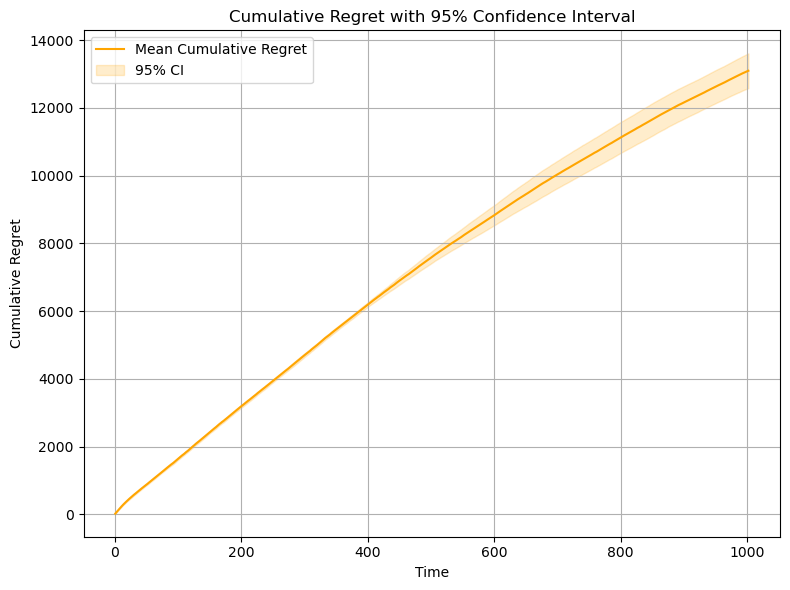

In [37]:
# Calculate the 95% confidence interval for the cumulative regret
lower_bound = cumulative_regret_mean - 1.96 * (cumulative_regret_std / np.sqrt(cumulative_regret_times.shape[0]))
upper_bound = cumulative_regret_mean + 1.96 * (cumulative_regret_std / np.sqrt(cumulative_regret_times.shape[0]))

# Plot the mean cumulative regret with confidence intervals
plt.figure(figsize=(8, 6))
time_steps = range(1, len(cumulative_regret_mean) + 1)

# Plot the mean line
plt.plot(time_steps, cumulative_regret_mean, label='Mean Cumulative Regret', color='orange')

# Fill the 95% confidence interval
plt.fill_between(time_steps, lower_bound, upper_bound, color='orange', alpha=0.2, label='95% CI')

# Add title, labels, and legend
plt.title('Cumulative Regret with 95% Confidence Interval')
plt.xlabel('Time')
plt.ylabel('Cumulative Regret')
plt.grid()
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()

In [38]:
np.save('cumulative_regret_SA-lasso-bandit-d100-s10_10times.npy', cumulative_regret_times)
np.save('l_2_error_parameter_SA-lasso-bandit-d100-s10_10times.npy', l_2_error_parameter_times)